In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Iterable
import pickle
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
AUT_ROUND_METADATA = {
    1: {
        "condition_id": "shoe",
        "condition_label": "Shoe",
        "object": "shoe",
        "common_use": "used as footwear",
    },
    2: {
        "condition_id": "button",
        "condition_label": "Button",
        "object": "button",
        "common_use": "used to fasten things",
    },
    3: {
        "condition_id": "key",
        "condition_label": "Key",
        "object": "key",
        "common_use": "used to open a lock",
    },
    4: {
        "condition_id": "wooden_pencil",
        "condition_label": "Wooden pencil",
        "object": "wooden pencil",
        "common_use": "used for writing",
    },
    5: {
        "condition_id": "automobile_tire",
        "condition_label": "Automobile tire",
        "object": "automobile tire",
        "common_use": "used on the wheel of an automobile",
    },
}

aut_conditions_df = pd.DataFrame([
    {"round_id": k, **v}
    for k, v in AUT_ROUND_METADATA.items()
])

aut_conditions_df

,round_id,condition_id,condition_label,object,common_use
0,1,shoe,Shoe,shoe,used as footwear
1,2,button,Button,button,used to fasten things
2,3,key,Key,key,used to open a lock
3,4,wooden_pencil,Wooden pencil,wooden pencil,used for writing
4,5,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile


In [3]:
def normalize_unicode(text: str) -> str:
    """Normalize unicode while preserving substantive text."""
    if pd.isna(text):
        return ""
    return unicodedata.normalize("NFKC", str(text))


def normalize_whitespace(text: str) -> str:
    """Collapse excess whitespace."""
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def clean_aut_idea(text: str) -> str:
    """
    Clean AUT idea text while preserving substantive content.

    Notes
    -----
    - Keeps punctuation because punctuation may separate object/use detail.
    - Removes only surrounding whitespace and wrapping quotation marks.
    """
    text = normalize_unicode(text)
    text = normalize_whitespace(text)
    text = re.sub(r"^['\"“”‘’]+|['\"“”‘’]+$", "", text).strip()
    text = normalize_whitespace(text)
    return text


def rough_word_count(text: str) -> int:
    """Approximate word count for AUT ideas."""
    text = clean_aut_idea(text)
    if not text:
        return 0
    return len(re.findall(r"\b[\w']+\b", text))


def char_count(text: str) -> int:
    """Character count after cleaning."""
    return len(clean_aut_idea(text))


def line_count(text: str) -> int:
    """Number of non-empty lines."""
    if pd.isna(text):
        return 0
    return len([ln for ln in str(text).splitlines() if ln.strip()])


def looks_like_multiple_ideas(text: str) -> bool:
    """
    Heuristic flag for cells that look like multiple ideas.
    Diagnostic only; do not filter by default.
    """
    if pd.isna(text):
        return False

    raw = str(text).strip()
    lines = [ln.strip() for ln in raw.splitlines() if ln.strip()]

    if len(lines) > 1:
        return True

    if re.search(r"(^|\n)\s*(\d+[\.\)]|[-*•])\s+", raw):
        return True

    # Semicolons or "or" can be legitimate in a single idea, so this is conservative.
    if raw.count(";") >= 2:
        return True

    return False


def has_aut_commentary(text: str) -> bool:
    """
    Heuristic flag for commentary rather than an idea.
    Diagnostic only.
    """
    text = clean_aut_idea(text).lower()
    if not text:
        return False

    commentary_patterns = [
        r"^idea:",
        r"^use:",
        r"^here('s| is)\b",
        r"^i would\b",
        r"^you could\b",
    ]

    # "You could..." may be a normal idea, so this flag is intentionally diagnostic only.
    return any(re.search(p, text) for p in commentary_patterns)

In [8]:
@dataclass
class AUTCorpus:
    """
    Container for human Alternative Uses Task data.

    Core design:
    - `records` stores one row per submitted idea.
    - `participant_id` identifies the human participant.
    - `round_id` / `condition_id` identify the object condition.
    - only turn_id == 1 is retained for the main benchmark.
    - original row/order identifiers are preserved.
    - exact duplicate ideas are retained because duplicates are part of the redundancy signal.
    - annotation_ali is retained as the primary manual bucket annotation.
    """
    records: pd.DataFrame
    source_path: str
    metadata: Dict = field(default_factory=dict)

    def __post_init__(self):
        required = {
            "idea_id",
            "source_id",
            "source_row_idx",
            "participant_id",
            "round_id",
            "turn_id",
            "condition_id",
            "condition_label",
            "object",
            "common_use",
            "idea_raw",
            "idea",
            "annotation_ali",
            "bucket_id",
            "word_count",
            "char_count",
        }
        missing = required - set(self.records.columns)
        if missing:
            raise ValueError(f"records is missing required columns: {sorted(missing)}")

    @property
    def n_ideas(self) -> int:
        return len(self.records)

    @property
    def n_participants(self) -> int:
        return self.records["participant_id"].nunique()

    @property
    def n_conditions(self) -> int:
        return self.records["condition_id"].nunique()

    def to_pickle(self, path: str | Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(self, f, protocol=pickle.HIGHEST_PROTOCOL)

    @staticmethod
    def from_pickle(path: str | Path) -> "AUTCorpus":
        with open(path, "rb") as f:
            return pickle.load(f)

    def get_records(
        self,
        participant_ids: Optional[Iterable[str]] = None,
        condition_ids: Optional[Iterable[str]] = None,
        round_ids: Optional[Iterable[int]] = None,
        min_words: Optional[int] = None,
        max_words: Optional[int] = None,
    ) -> pd.DataFrame:
        """Return filtered records as a copy."""
        df = self.records

        if participant_ids is not None:
            df = df[df["participant_id"].isin(list(participant_ids))]

        if condition_ids is not None:
            df = df[df["condition_id"].isin(list(condition_ids))]

        if round_ids is not None:
            df = df[df["round_id"].isin(list(round_ids))]

        if min_words is not None:
            df = df[df["word_count"] >= min_words]

        if max_words is not None:
            df = df[df["word_count"] <= max_words]

        return df.copy()

    def condition_summary(self) -> pd.DataFrame:
        """Summarize response counts and idea lengths by object condition."""
        return (
            self.records
            .groupby(["round_id", "condition_id", "condition_label", "object", "common_use"], as_index=False)
            .agg(
                n_ideas=("idea", "size"),
                n_unique_ideas=("idea", "nunique"),
                n_participants=("participant_id", "nunique"),
                mean_ideas_per_participant=("participant_id", lambda x: len(x) / x.nunique()),
                mean_words=("word_count", "mean"),
                median_words=("word_count", "median"),
                min_words=("word_count", "min"),
                max_words=("word_count", "max"),
                n_empty=("empty_idea", "sum"),
                n_multiple_like=("looks_like_multiple_ideas", "sum"),
                n_unique_buckets=("bucket_id", "nunique"),
            )
            .sort_values("round_id")
            .reset_index(drop=True)
        )

    def participant_summary(self) -> pd.DataFrame:
        """Summarize total and condition-specific idea counts by participant."""
        base = (
            self.records
            .groupby("participant_id", as_index=False)
            .agg(
                n_ideas=("idea", "size"),
                n_unique_ideas=("idea", "nunique"),
                n_conditions=("condition_id", "nunique"),
                mean_words=("word_count", "mean"),
                median_words=("word_count", "median"),
                min_words=("word_count", "min"),
                max_words=("word_count", "max"),
            )
        )

        wide_counts = (
            self.records
            .pivot_table(
                index="participant_id",
                columns="condition_id",
                values="idea",
                aggfunc="size",
                fill_value=0,
            )
            .reset_index()
        )

        out = base.merge(wide_counts, on="participant_id", how="left")
        return out.sort_values(["n_ideas", "participant_id"], ascending=[False, True]).reset_index(drop=True)

    def bucket_summary(self) -> pd.DataFrame:
        """Summarize manual annotation buckets by condition."""
        return (
            self.records
            .groupby(["condition_id", "bucket_id"], as_index=False)
            .agg(
                n_ideas=("idea", "size"),
                n_participants=("participant_id", "nunique"),
                example_idea=("idea", "first"),
            )
            .sort_values(["condition_id", "n_ideas"], ascending=[True, False])
            .reset_index(drop=True)
        )

    def sample_one_idea_per_participant_condition(
        self,
        random_state: int = 42,
    ) -> pd.DataFrame:
        """
        Sample one idea per participant per object condition.

        This is useful for matched human-vs-AI bootstrapping when the human unit
        should mirror one AI generation per object/prompt.
        """
        df = self.records.copy()

        sampled = (
            df.groupby(["participant_id", "condition_id"], group_keys=False)
              .sample(n=1, random_state=random_state)
              .sort_values(["condition_id", "participant_id"])
              .reset_index(drop=True)
        )

        return sampled

    def show_examples(
        self,
        condition_id: Optional[str] = None,
        n: int = 20,
        random_state: int = 42,
        participant_id: Optional[str] = None,
    ) -> None:
        """Print sample AUT ideas."""
        df = self.records.copy()

        if condition_id is not None:
            df = df[df["condition_id"] == condition_id]

        if participant_id is not None:
            df = df[df["participant_id"] == participant_id]

        if df.empty:
            print("No records found.")
            return

        sample = df.sample(n=min(n, len(df)), random_state=random_state)

        for i, (_, row) in enumerate(sample.iterrows(), start=1):
            print("=" * 80)
            print(f"EXAMPLE {i}")
            print(
                f"participant_id={row['participant_id']} | "
                f"condition={row['condition_id']} | "
                f"source_id={row['source_id']} | "
                f"bucket={row['bucket_id']} | "
                f"words={row['word_count']}"
            )
            print("-" * 80)
            print(row["idea"])

In [9]:
def load_aut_corpus(
    csv_path: str | Path = "human_data/AUTData/df_annotated_ali_krish.csv",
    round_metadata: Dict[int, Dict] = AUT_ROUND_METADATA,
    keep_turn_id: int = 1,
) -> AUTCorpus:
    """
    Load human AUT data from CSV into a reusable corpus object.

    Expected columns:
    - id
    - for_user_id
    - round_id
    - turn_id
    - idea_content
    - idea_content2
    - annotation_ali
    - annotation_krish

    Main benchmark decision:
    - keep only turn_id == 1
    - keep idea_content as the submitted text
    - keep annotation_ali as primary manual bucket
    - ignore idea_content2 and annotation_krish
    """
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"Missing AUT CSV: {csv_path}")

    raw = pd.read_csv(csv_path)

    expected = {
        "id",
        "for_user_id",
        "round_id",
        "turn_id",
        "idea_content",
        "idea_content2",
        "annotation_ali",
        "annotation_krish",
    }
    missing = expected - set(raw.columns)
    if missing:
        raise ValueError(f"Input CSV is missing expected columns: {sorted(missing)}")

    raw = raw.copy()
    raw.insert(0, "source_row_idx", np.arange(len(raw), dtype=int))

    # Keep only first-turn, individually generated ideas.
    df = raw[raw["turn_id"] == keep_turn_id].copy()

    df["source_id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")
    df["participant_id"] = df["for_user_id"].astype(str)
    df["round_id"] = pd.to_numeric(df["round_id"], errors="coerce").astype("Int64")
    df["turn_id"] = pd.to_numeric(df["turn_id"], errors="coerce").astype("Int64")

    # Attach task metadata.
    meta_df = pd.DataFrame([
        {"round_id": int(k), **v}
        for k, v in round_metadata.items()
    ])
    meta_df["round_id"] = meta_df["round_id"].astype("Int64")

    df = df.merge(meta_df, on="round_id", how="left", validate="many_to_one")

    missing_meta = df[df["condition_id"].isna()]["round_id"].dropna().unique().tolist()
    if missing_meta:
        raise ValueError(f"No round metadata found for round_id values: {missing_meta}")

    df["idea_raw"] = df["idea_content"]
    df["idea"] = df["idea_raw"].map(clean_aut_idea)

    df["annotation_ali"] = pd.to_numeric(df["annotation_ali"], errors="coerce").astype("Int64")
    df["bucket_id"] = df["annotation_ali"]

    df["word_count"] = df["idea"].map(rough_word_count).astype(int)
    df["char_count"] = df["idea"].map(char_count).astype(int)
    df["line_count"] = df["idea_raw"].map(line_count).astype(int)

    df["empty_idea"] = df["idea"].eq("")
    df["looks_like_multiple_ideas"] = df["idea_raw"].map(looks_like_multiple_ideas)
    df["has_commentary"] = df["idea_raw"].map(has_aut_commentary)

    # Diagnostic only. Keep all ideas in the main curated dataset.
    df["valid_idea_heuristic"] = (
        (~df["empty_idea"])
        & (df["word_count"] >= 1)
        & (~df["looks_like_multiple_ideas"])
    )

    # Preserve ordering by source id within participant/object.
    # If id order is descending in raw capture, sort ascending by source_id as the stable production sequence.
    df = df.sort_values(
        ["participant_id", "round_id", "source_id", "source_row_idx"],
        na_position="last"
    ).reset_index(drop=True)

    df.insert(0, "idea_id", np.arange(len(df), dtype=int))

    cols = [
        "idea_id",
        "source_id",
        "source_row_idx",
        "participant_id",
        "round_id",
        "turn_id",
        "condition_id",
        "condition_label",
        "object",
        "common_use",
        "idea_raw",
        "idea",
        "annotation_ali",
        "bucket_id",
        "word_count",
        "char_count",
        "line_count",
        "empty_idea",
        "looks_like_multiple_ideas",
        "has_commentary",
        "valid_idea_heuristic",
    ]

    records = df[cols].copy()

    metadata = {
        "source_path": str(csv_path),
        "keep_turn_id": keep_turn_id,
        "round_metadata": round_metadata,
        "n_raw_rows": int(len(raw)),
        "n_retained_rows": int(len(records)),
        "n_removed_other_turns": int(len(raw) - len(records)),
        "n_participants": int(records["participant_id"].nunique()),
        "n_conditions": int(records["condition_id"].nunique()),
        "n_unique_ideas": int(records["idea"].nunique()),
        "created_by": "load_aut_corpus",
        "notes": (
            "Only turn_id == 1 is retained. idea_content2 and annotation_krish are ignored. "
            "annotation_ali is retained as the primary manual bucket. Exact duplicate ideas are retained."
        ),
    }

    corpus = AUTCorpus(
        records=records,
        source_path=str(csv_path),
        metadata=metadata,
    )

    print("Loaded AUT corpus")
    print(f"  Source:                 {csv_path}")
    print(f"  Raw rows:               {len(raw):,}")
    print(f"  Retained turn_id={keep_turn_id}: {len(records):,}")
    print(f"  Removed other turns:    {len(raw) - len(records):,}")
    print(f"  Participants:           {corpus.n_participants:,}")
    print(f"  Conditions:             {corpus.n_conditions:,}")
    print(f"  Unique ideas:           {records['idea'].nunique():,}")
    print()
    print("Validity diagnostics")
    print(f"  Empty ideas:            {int(records['empty_idea'].sum()):,}")
    print(f"  Multiple-like ideas:    {int(records['looks_like_multiple_ideas'].sum()):,}")
    print(f"  Commentary-like ideas:  {int(records['has_commentary'].sum()):,}")
    print(f"  Missing bucket IDs:     {int(records['bucket_id'].isna().sum()):,}")

    return corpus


aut_corpus = load_aut_corpus(
    csv_path="human_data/AUTData/df_annotated_ali_krish.csv",
    round_metadata=AUT_ROUND_METADATA,
    keep_turn_id=1,
)

aut_corpus.records.head(20)

Loaded AUT corpus
  Source:                 human_data/AUTData/df_annotated_ali_krish.csv
  Raw rows:               5,703
  Retained turn_id=1: 3,047
  Removed other turns:    2,656
  Participants:           109
  Conditions:             5
  Unique ideas:           2,764

Validity diagnostics
  Empty ideas:            0
  Multiple-like ideas:    0
  Commentary-like ideas:  2
  Missing bucket IDs:     0


,idea_id,source_id,source_row_idx,participant_id,round_id,turn_id,condition_id,condition_label,object,common_use,...,idea,annotation_ali,bucket_id,word_count,char_count,line_count,empty_idea,looks_like_multiple_ideas,has_commentary,valid_idea_heuristic
0,0,3699,2240,100,1,1,shoe,Shoe,shoe,used as footwear,...,Swatting Flies,18,18,2,14,1,False,False,False,True
1,1,3700,2239,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a hat,177,177,4,13,1,False,False,False,True
2,2,3701,2238,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a pot for a plant,266,266,7,25,1,False,False,False,True
3,3,3702,2237,100,1,1,shoe,Shoe,shoe,used as footwear,...,Contain dripping leaks,133,133,3,22,1,False,False,False,True
4,4,3703,2236,100,1,1,shoe,Shoe,shoe,used as footwear,...,Drumming,371,371,1,8,1,False,False,False,True
5,5,3704,2235,100,1,1,shoe,Shoe,shoe,used as footwear,...,Doorstopper,113,113,1,11,1,False,False,False,True
6,6,3792,2250,100,2,1,button,Button,button,used to fasten things,...,Flick at people as a weapon,21,21,6,27,1,False,False,False,True
7,7,3793,2249,100,2,1,button,Button,button,used to fasten things,...,Drawing circles on paper,28,28,4,24,1,False,False,False,True
8,8,3794,2248,100,2,1,button,Button,button,used to fasten things,...,Wheels for a toy car,60,60,5,20,1,False,False,False,True
9,9,3795,2247,100,2,1,button,Button,button,used to fasten things,...,Lid for a very tiny pot,227,227,6,23,1,False,False,False,True


In [10]:
condition_summary = aut_corpus.condition_summary()
participant_summary = aut_corpus.participant_summary()
bucket_summary = aut_corpus.bucket_summary()

display(condition_summary)
display(participant_summary.head(20))
display(bucket_summary.head(30))

print("Participant idea-count distribution")
display(participant_summary["n_ideas"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("\nIdea word-count distribution")
display(aut_corpus.records["word_count"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("\nIdeas per participant-condition")
participant_condition_counts = (
    aut_corpus.records
    .groupby(["participant_id", "condition_id"])
    .size()
    .reset_index(name="n_ideas")
)
display(participant_condition_counts["n_ideas"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

,round_id,condition_id,condition_label,object,common_use,n_ideas,n_unique_ideas,n_participants,mean_ideas_per_participant,mean_words,median_words,min_words,max_words,n_empty,n_multiple_like,n_unique_buckets
0,1,shoe,Shoe,shoe,used as footwear,604,532,109,5.541284,4.114238,3.0,1,27,0,0,207
1,2,button,Button,button,used to fasten things,603,583,109,5.532110,5.296849,4.0,1,28,0,0,237
2,3,key,Key,key,used to open a lock,612,574,109,5.614679,5.558824,4.0,1,33,0,0,194
3,4,wooden_pencil,Wooden pencil,wooden pencil,used for writing,613,583,109,5.623853,5.557912,4.0,1,30,0,0,242
4,5,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,615,575,109,5.642202,5.986992,5.0,1,28,0,0,262


,participant_id,n_ideas,n_unique_ideas,n_conditions,mean_words,median_words,min_words,max_words,automobile_tire,button,key,shoe,wooden_pencil
0,100,30,30,5,5.633333,6.0,1,15,6,6,6,6,6
1,101,30,30,5,4.033333,4.0,2,7,6,6,6,6,6
2,103,30,30,5,10.300000,10.5,2,19,6,6,6,6,6
3,104,30,30,5,6.966667,7.0,2,15,6,6,6,6,6
4,107,30,30,5,6.300000,7.0,1,14,6,6,6,6,6
5,109,30,30,5,4.200000,3.5,1,10,6,6,6,6,6
6,110,30,30,5,4.033333,3.5,2,9,6,6,6,6,6
7,111,30,27,5,4.666667,5.0,1,15,6,6,6,6,6
8,113,30,28,5,2.466667,2.0,1,6,6,6,6,6,6
9,114,30,30,5,2.233333,2.0,1,6,6,6,6,6,6


,condition_id,bucket_id,n_ideas,n_participants,example_idea
0,automobile_tire,7,57,57,Make a tire swing
1,automobile_tire,31,35,34,Use them for mini raised garden beds
2,automobile_tire,12,26,26,Seat for rolling down a hill
3,automobile_tire,54,16,16,Basis for a picnic table
4,automobile_tire,91,16,16,Weight for working out
5,automobile_tire,22,14,13,use as a chair on ground add cushion to top
6,automobile_tire,47,12,12,Use it in an obstacle course
7,automobile_tire,66,11,11,Turn it into a large dog bed
8,automobile_tire,15,10,10,as a tool for raising fire
9,automobile_tire,61,10,10,Lay it flat and fill it with soil and make a g...


Participant idea-count distribution


count    109.000000
mean      27.954128
std        3.004273
min       20.000000
25%       27.000000
50%       30.000000
75%       30.000000
90%       30.000000
95%       30.000000
99%       30.000000
max       30.000000
Name: n_ideas, dtype: float64


Idea word-count distribution


count    3047.000000
mean        5.306859
std         4.073362
min         1.000000
25%         2.000000
50%         4.000000
75%         7.000000
90%        11.000000
95%        13.000000
99%        19.000000
max        33.000000
Name: word_count, dtype: float64


Ideas per participant-condition


count    545.000000
mean       5.590826
std        0.729819
min        4.000000
25%        5.000000
50%        6.000000
75%        6.000000
90%        6.000000
95%        6.000000
99%        6.000000
max        6.000000
Name: n_ideas, dtype: float64

In [11]:
# Check monotonic source_id order within participant and condition.
ordering_check = (
    aut_corpus.records
    .groupby(["participant_id", "condition_id"])
    .agg(
        n_ideas=("idea", "size"),
        min_source_id=("source_id", "min"),
        max_source_id=("source_id", "max"),
        source_id_is_monotonic=("source_id", lambda x: x.dropna().is_monotonic_increasing),
    )
    .reset_index()
)

print("Participant-condition cells with non-monotonic source_id after sorting:")
display(ordering_check.query("source_id_is_monotonic == False"))

# Participant coverage across object conditions.
coverage = (
    aut_corpus.records
    .groupby("participant_id")
    .agg(
        n_conditions=("condition_id", "nunique"),
        conditions=("condition_id", lambda x: ",".join(sorted(set(x)))),
        n_ideas=("idea", "size"),
    )
    .reset_index()
)

print("Coverage by number of object conditions:")
display(coverage["n_conditions"].value_counts().sort_index())

print("Participants missing at least one object condition:")
display(coverage.query("n_conditions < 5").head(30))

Participant-condition cells with non-monotonic source_id after sorting:


,participant_id,condition_id,n_ideas,min_source_id,max_source_id,source_id_is_monotonic


Coverage by number of object conditions:


n_conditions
5    109
Name: count, dtype: int64

Participants missing at least one object condition:


,participant_id,n_conditions,conditions,n_ideas


In [12]:
duplicate_summary = (
    aut_corpus.records
    .groupby(["condition_id", "idea"], as_index=False)
    .agg(
        n_occurrences=("idea", "size"),
        n_participants=("participant_id", "nunique"),
        example_idea_id=("idea_id", "first"),
        bucket_ids=("bucket_id", lambda x: ",".join(map(str, sorted(set(x.dropna().astype(int)))))),
    )
    .sort_values(["condition_id", "n_occurrences", "n_participants"], ascending=[True, False, False])
    .reset_index(drop=True)
)

display(duplicate_summary.head(50))

bucket_condition_summary = (
    aut_corpus.records
    .groupby(["condition_id", "bucket_id"], as_index=False)
    .agg(
        n_ideas=("idea", "size"),
        n_participants=("participant_id", "nunique"),
        example_idea=("idea", "first"),
    )
    .sort_values(["condition_id", "n_ideas"], ascending=[True, False])
    .reset_index(drop=True)
)

display(bucket_condition_summary.head(50))

,condition_id,idea,n_occurrences,n_participants,example_idea_id,bucket_ids
0,automobile_tire,tire swing,8,8,547,7
1,automobile_tire,planter,7,7,197,31
2,automobile_tire,Swing,5,5,578,7
3,automobile_tire,As a planter,3,3,1750,31
4,automobile_tire,Dog bed,3,3,289,66
5,automobile_tire,dog bed,3,3,1275,66
6,automobile_tire,sandbox,3,3,687,72
7,automobile_tire,swing,3,3,630,7
8,automobile_tire,As a swing,2,2,1473,7
9,automobile_tire,Exercise equipment,2,2,1584,75


,condition_id,bucket_id,n_ideas,n_participants,example_idea
0,automobile_tire,7,57,57,Make a tire swing
1,automobile_tire,31,35,34,Use them for mini raised garden beds
2,automobile_tire,12,26,26,Seat for rolling down a hill
3,automobile_tire,54,16,16,Basis for a picnic table
4,automobile_tire,91,16,16,Weight for working out
5,automobile_tire,22,14,13,use as a chair on ground add cushion to top
6,automobile_tire,47,12,12,Use it in an obstacle course
7,automobile_tire,66,11,11,Turn it into a large dog bed
8,automobile_tire,15,10,10,as a tool for raising fire
9,automobile_tire,61,10,10,Lay it flat and fill it with soil and make a g...


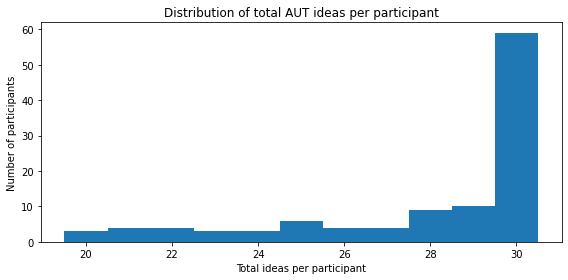

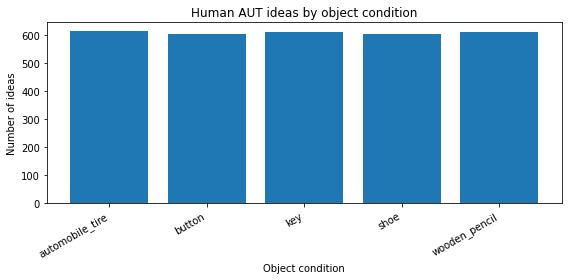

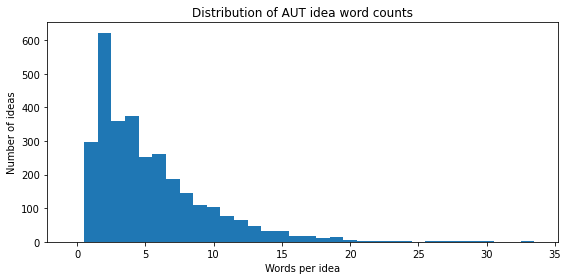

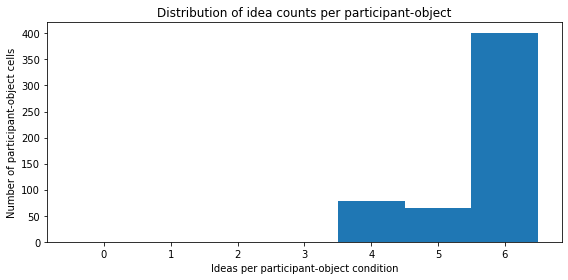

In [13]:
def plot_aut_diagnostics(corpus: AUTCorpus) -> None:
    records = corpus.records
    participant_summary = corpus.participant_summary()

    plt.figure(figsize=(8, 4))
    counts = participant_summary["n_ideas"]
    bins = np.arange(counts.min(), counts.max() + 2) - 0.5
    plt.hist(counts, bins=bins)
    plt.xlabel("Total ideas per participant")
    plt.ylabel("Number of participants")
    plt.title("Distribution of total AUT ideas per participant")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    by_condition = (
        records.groupby("condition_id")
        .size()
        .sort_index()
    )
    plt.bar(by_condition.index.astype(str), by_condition.values)
    plt.xlabel("Object condition")
    plt.ylabel("Number of ideas")
    plt.title("Human AUT ideas by object condition")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    bins = np.arange(0, max(records["word_count"].max(), 20) + 2) - 0.5
    plt.hist(records["word_count"], bins=bins)
    plt.xlabel("Words per idea")
    plt.ylabel("Number of ideas")
    plt.title("Distribution of AUT idea word counts")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    participant_condition_counts = (
        records.groupby(["participant_id", "condition_id"])
        .size()
        .reset_index(name="n_ideas")
    )
    plt.hist(participant_condition_counts["n_ideas"], bins=np.arange(0, participant_condition_counts["n_ideas"].max() + 2) - 0.5)
    plt.xlabel("Ideas per participant-object condition")
    plt.ylabel("Number of participant-object cells")
    plt.title("Distribution of idea counts per participant-object")
    plt.tight_layout()
    plt.show()


plot_aut_diagnostics(aut_corpus)

In [14]:
aut_corpus.show_examples(n=20, random_state=7)

EXAMPLE 1
participant_id=146 | condition=key | source_id=6155 | bucket=33 | words=1
--------------------------------------------------------------------------------
jewelry
EXAMPLE 2
participant_id=157 | condition=button | source_id=6128 | bucket=3 | words=2
--------------------------------------------------------------------------------
making art
EXAMPLE 3
participant_id=59 | condition=key | source_id=1907 | bucket=62 | words=3
--------------------------------------------------------------------------------
key walla rrt
EXAMPLE 4
participant_id=116 | condition=key | source_id=4580 | bucket=57 | words=3
--------------------------------------------------------------------------------
Mail / Box opener
EXAMPLE 5
participant_id=156 | condition=button | source_id=6094 | bucket=15 | words=11
--------------------------------------------------------------------------------
put into a sealed can to use as a noise maker
EXAMPLE 6
participant_id=64 | condition=key | source_id=2283 | bucket=99 

In [15]:
for condition_id in aut_conditions_df["condition_id"]:
    print("\n" + "#" * 100)
    print(condition_id)
    aut_corpus.show_examples(condition_id=condition_id, n=8, random_state=7)


####################################################################################################
shoe
EXAMPLE 1
participant_id=167 | condition=shoe | source_id=6266 | bucket=112 | words=1
--------------------------------------------------------------------------------
hammer
EXAMPLE 2
participant_id=158 | condition=shoe | source_id=5967 | bucket=527 | words=5
--------------------------------------------------------------------------------
A container for loose objects
EXAMPLE 3
participant_id=130 | condition=shoe | source_id=5354 | bucket=324 | words=7
--------------------------------------------------------------------------------
Use the shoelaces to tie something up
EXAMPLE 4
participant_id=155 | condition=shoe | source_id=5849 | bucket=55 | words=1
--------------------------------------------------------------------------------
planter
EXAMPLE 5
participant_id=134 | condition=shoe | source_id=5494 | bucket=18 | words=2
----------------------------------------------------------

In [16]:
example_participant = aut_corpus.records["participant_id"].iloc[0]

print("Example participant:", example_participant)

(
    aut_corpus
    .get_records(participant_ids=[example_participant])
    .sort_values(["round_id", "source_id"])
    [["participant_id", "round_id", "condition_id", "source_id", "idea", "bucket_id", "word_count"]]
)

Example participant: 100


,participant_id,round_id,condition_id,source_id,idea,bucket_id,word_count
0,100,1,shoe,3699,Swatting Flies,18,2
1,100,1,shoe,3700,Used as a hat,177,4
2,100,1,shoe,3701,Used as a pot for a plant,266,7
3,100,1,shoe,3702,Contain dripping leaks,133,3
4,100,1,shoe,3703,Drumming,371,1
5,100,1,shoe,3704,Doorstopper,113,1
6,100,2,button,3792,Flick at people as a weapon,21,6
7,100,2,button,3793,Drawing circles on paper,28,4
8,100,2,button,3794,Wheels for a toy car,60,5
9,100,2,button,3795,Lid for a very tiny pot,227,6


In [17]:
human_aut_df = aut_corpus.records.copy()

print("Full human AUT dataset")
print(f"  Rows / ideas:       {len(human_aut_df):,}")
print(f"  Participants:       {human_aut_df['participant_id'].nunique():,}")
print(f"  Conditions:         {human_aut_df['condition_id'].nunique():,}")
print(f"  Unique ideas:       {human_aut_df['idea'].nunique():,}")
print(f"  Unique buckets:     {human_aut_df['bucket_id'].nunique():,}")
print()
print(human_aut_df["valid_idea_heuristic"].value_counts(dropna=False))

human_aut_df.head()

Full human AUT dataset
  Rows / ideas:       3,047
  Participants:       109
  Conditions:         5
  Unique ideas:       2,764
  Unique buckets:     490

valid_idea_heuristic
True    3047
Name: count, dtype: int64


,idea_id,source_id,source_row_idx,participant_id,round_id,turn_id,condition_id,condition_label,object,common_use,...,idea,annotation_ali,bucket_id,word_count,char_count,line_count,empty_idea,looks_like_multiple_ideas,has_commentary,valid_idea_heuristic
0,0,3699,2240,100,1,1,shoe,Shoe,shoe,used as footwear,...,Swatting Flies,18,18,2,14,1,False,False,False,True
1,1,3700,2239,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a hat,177,177,4,13,1,False,False,False,True
2,2,3701,2238,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a pot for a plant,266,266,7,25,1,False,False,False,True
3,3,3702,2237,100,1,1,shoe,Shoe,shoe,used as footwear,...,Contain dripping leaks,133,133,3,22,1,False,False,False,True
4,4,3703,2236,100,1,1,shoe,Shoe,shoe,used as footwear,...,Drumming,371,371,1,8,1,False,False,False,True


In [18]:
sampled_one_per_participant_condition_df = aut_corpus.sample_one_idea_per_participant_condition(
    random_state=42
)

print("Sampled one idea per participant-condition")
print(f"  Rows:             {len(sampled_one_per_participant_condition_df):,}")
print(f"  Participants:     {sampled_one_per_participant_condition_df['participant_id'].nunique():,}")
print(f"  Conditions:       {sampled_one_per_participant_condition_df['condition_id'].nunique():,}")

display(
    sampled_one_per_participant_condition_df
    .groupby("condition_id")
    .agg(
        n_ideas=("idea", "size"),
        n_participants=("participant_id", "nunique"),
        n_unique_ideas=("idea", "nunique"),
        n_unique_buckets=("bucket_id", "nunique"),
    )
    .reset_index()
)

sampled_one_per_participant_condition_df.head(20)

Sampled one idea per participant-condition
  Rows:             545
  Participants:     109
  Conditions:       5


,condition_id,n_ideas,n_participants,n_unique_ideas,n_unique_buckets
0,automobile_tire,109,109,108,77
1,button,109,109,105,59
2,key,109,109,107,63
3,shoe,109,109,105,59
4,wooden_pencil,109,109,106,78


,idea_id,source_id,source_row_idx,participant_id,round_id,turn_id,condition_id,condition_label,object,common_use,...,idea,annotation_ali,bucket_id,word_count,char_count,line_count,empty_idea,looks_like_multiple_ideas,has_commentary,valid_idea_heuristic
0,24,4445,2280,100,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,Roll at people to distract them,302,302,6,31,1,False,False,False,True
1,59,5131,2333,101,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,Weight for working out,91,91,4,22,1,False,False,False,True
2,86,4438,2389,102,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,Fashion a rat trap using the tire,318,318,7,33,1,False,False,False,True
3,116,5330,2441,103,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,cut up for ground cover,357,357,5,23,1,False,False,False,True
4,146,4766,2499,104,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,Use them for mini raised garden beds,31,31,7,36,1,False,False,False,True
5,170,5051,2551,105,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,as a wedge,228,228,3,10,1,False,False,False,True
6,198,5067,2602,106,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,grind up and make playground filler,303,303,6,35,1,False,False,False,True
7,229,5160,2653,107,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,paint and turn into mixed media art,101,101,7,35,1,False,False,False,True
8,261,4819,2701,109,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,A stand,261,261,2,7,1,False,False,False,True
9,289,4770,2755,110,5,1,automobile_tire,Automobile tire,automobile tire,used on the wheel of an automobile,...,Dog bed,66,66,2,7,1,False,False,False,True


In [19]:
CACHE_DIR = Path("human_data/cache")
PILOT_DIR = Path("human_data/pilot")
AUT_OUT_DIR = Path("human_data/AUTData/processed")

for p in [CACHE_DIR, PILOT_DIR, AUT_OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Reusable object.
corpus_pickle_path = CACHE_DIR / "aut_corpus.pkl"
aut_corpus.to_pickle(corpus_pickle_path)

# Full benchmark-ready human AUT data.
full_pkl = PILOT_DIR / "aut_human_ideas_turn1.pkl"
full_csv = PILOT_DIR / "aut_human_ideas_turn1.csv"

human_aut_df.to_pickle(full_pkl)
human_aut_df.to_csv(full_csv, index=False)

# Summary files.
conditions_csv = PILOT_DIR / "aut_human_condition_summary.csv"
participants_csv = PILOT_DIR / "aut_human_participant_summary.csv"
buckets_csv = PILOT_DIR / "aut_human_bucket_summary.csv"
duplicates_csv = PILOT_DIR / "aut_human_duplicate_summary.csv"
round_metadata_csv = PILOT_DIR / "aut_round_metadata.csv"

condition_summary.to_csv(conditions_csv, index=False)
participant_summary.to_csv(participants_csv, index=False)
bucket_condition_summary.to_csv(buckets_csv, index=False)
duplicate_summary.to_csv(duplicates_csv, index=False)
aut_conditions_df.to_csv(round_metadata_csv, index=False)

# Optional deterministic sampled view.
sampled_pkl = PILOT_DIR / "aut_human_ideas_one_per_participant_condition_seed42.pkl"
sampled_csv = PILOT_DIR / "aut_human_ideas_one_per_participant_condition_seed42.csv"

sampled_one_per_participant_condition_df.to_pickle(sampled_pkl)
sampled_one_per_participant_condition_df.to_csv(sampled_csv, index=False)

# Also save into source-specific processed directory.
human_aut_df.to_pickle(AUT_OUT_DIR / "aut_human_ideas_turn1.pkl")
human_aut_df.to_csv(AUT_OUT_DIR / "aut_human_ideas_turn1.csv", index=False)
aut_conditions_df.to_csv(AUT_OUT_DIR / "aut_round_metadata.csv", index=False)

print("Saved:")
print(corpus_pickle_path)
print(full_pkl)
print(full_csv)
print(conditions_csv)
print(participants_csv)
print(buckets_csv)
print(duplicates_csv)
print(round_metadata_csv)
print(sampled_pkl)
print(sampled_csv)
print(AUT_OUT_DIR / "aut_human_ideas_turn1.pkl")
print(AUT_OUT_DIR / "aut_human_ideas_turn1.csv")
print(AUT_OUT_DIR / "aut_round_metadata.csv")

Saved:
human_data/cache/aut_corpus.pkl
human_data/pilot/aut_human_ideas_turn1.pkl
human_data/pilot/aut_human_ideas_turn1.csv
human_data/pilot/aut_human_condition_summary.csv
human_data/pilot/aut_human_participant_summary.csv
human_data/pilot/aut_human_bucket_summary.csv
human_data/pilot/aut_human_duplicate_summary.csv
human_data/pilot/aut_round_metadata.csv
human_data/pilot/aut_human_ideas_one_per_participant_condition_seed42.pkl
human_data/pilot/aut_human_ideas_one_per_participant_condition_seed42.csv
human_data/AUTData/processed/aut_human_ideas_turn1.pkl
human_data/AUTData/processed/aut_human_ideas_turn1.csv
human_data/AUTData/processed/aut_round_metadata.csv


In [20]:
reloaded_aut_corpus = AUTCorpus.from_pickle("human_data/cache/aut_corpus.pkl")

print("Reloaded AUT corpus")
print(f"  Total ideas:   {reloaded_aut_corpus.n_ideas:,}")
print(f"  Participants:  {reloaded_aut_corpus.n_participants:,}")
print(f"  Conditions:    {reloaded_aut_corpus.n_conditions:,}")

reloaded_df = pd.read_pickle("human_data/pilot/aut_human_ideas_turn1.pkl")
print(reloaded_df.shape)
reloaded_df.head()

Reloaded AUT corpus
  Total ideas:   3,047
  Participants:  109
  Conditions:    5
(3047, 21)


,idea_id,source_id,source_row_idx,participant_id,round_id,turn_id,condition_id,condition_label,object,common_use,...,idea,annotation_ali,bucket_id,word_count,char_count,line_count,empty_idea,looks_like_multiple_ideas,has_commentary,valid_idea_heuristic
0,0,3699,2240,100,1,1,shoe,Shoe,shoe,used as footwear,...,Swatting Flies,18,18,2,14,1,False,False,False,True
1,1,3700,2239,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a hat,177,177,4,13,1,False,False,False,True
2,2,3701,2238,100,1,1,shoe,Shoe,shoe,used as footwear,...,Used as a pot for a plant,266,266,7,25,1,False,False,False,True
3,3,3702,2237,100,1,1,shoe,Shoe,shoe,used as footwear,...,Contain dripping leaks,133,133,3,22,1,False,False,False,True
4,4,3703,2236,100,1,1,shoe,Shoe,shoe,used as footwear,...,Drumming,371,371,1,8,1,False,False,False,True
